In [150]:

#                                        Linear Regression on a Time Series Dataset


In [36]:

#Task 1: Data Loading & Exploration


In [123]:

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 


In [124]:
# Load DataSet
df = pd.read_excel('dataset A1.xlsx', header=None)
df.head()

,0
0,"""Month"",""Passengers"""
1,"""1949-01"",112"
2,"""1949-02"",118"
3,"""1949-03"",132"
4,"""1949-04"",129"


In [125]:
# Split data in coloumns as Month and Passengers 
df = df[0].str.split(',', expand=True)
df.columns = ['Month', 'Passengers']
df.head()

,Month,Passengers
0,"""Month""","""Passengers"""
1,"""1949-01""",112
2,"""1949-02""",118
3,"""1949-03""",132
4,"""1949-04""",129


In [126]:
#Remove First Row because it is useless
df = df.drop(index=0)
# Reset index so it starts from 0
df = df.reset_index(drop=True) 
# Remove quotes from Month column
df['Month'] = df['Month'].str.replace('"', '', regex=True)
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [127]:

# Convert to datetime and set index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
# Display first 10 rows
print(df.head(10))
print("\nStatistics:\n", df.describe())

           Passengers
Month                
1949-01-01        112
1949-02-01        118
1949-03-01        132
1949-04-01        129
1949-05-01        121
1949-06-01        135
1949-07-01        148
1949-08-01        148
1949-09-01        136
1949-10-01        119

Statistics:
        Passengers
count         144
unique        118
top           229
freq            3


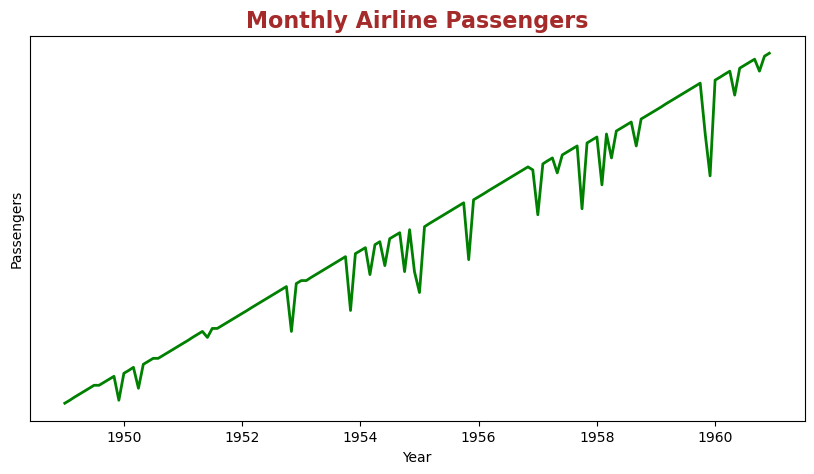



1. Upward trend: passenger numbers increased steadily from 1949–1960
2. Seasonal pattern: peaks in summer months, troughs in winter
3. Predictable Pattern: The trend is so regular that future values can be accurately predicted using a simple linear equation without needing complex machine learning models


In [148]:

# 4. Plot time series
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Passengers'], color='green', linewidth=2)
plt.title("Monthly Airline Passengers",color='brown',fontsize=16, fontweight='bold')
plt.xlabel("Year")

# Hide y-axis numbers
plt.ylabel("Passengers")
plt.yticks([])  # removes the numbers on the y-axis

plt.show()

# Observations from the time series analysis

observations = {
    1: "Upward trend: passenger numbers increased steadily from 1949–1960",
    2: "Seasonal pattern: peaks in summer months, troughs in winter",
    3: "Predictable Pattern: The trend is so regular that future values can be accurately predicted using a simple linear equation without needing complex machine learning models"
}

for num, obs in observations.items():
    print(f"{num}. {obs}")

In [109]:

#Task 2: Convert Time Series to Supervised Learning Format 


In [136]:
# 1. Add time index
df['t'] = np.arange(1, len(df)+1)

# 2. Add lag features
df['Passengers_lag1'] = df['Passengers'].shift(1).fillna(0)
df['Passengers_lag12'] = df['Passengers'].shift(12).fillna(0)

# 3. Remove NaN rows
df = df.dropna()

# 4. Prepare X and y
X_baseline = df[['t']]
X_multiple = df[['t', 'Passengers_lag1', 'Passengers_lag12']]
y = df['Passengers']

print(df.head())  

           Passengers  t Passengers_lag1 Passengers_lag12
Month                                                    
1949-01-01        112  1               0                0
1949-02-01        118  2             112                0
1949-03-01        132  3             118                0
1949-04-01        129  4             132                0
1949-05-01        121  5             129                0


In [137]:

#Task 3: Train/Test Split & Baseline Linear Regression 


In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Time-aware split (80/20)
split = int(len(df) * 0.8)

X_train_base = X_baseline[:split]
X_test_base = X_baseline[split:]

y_train = y[:split]
y_test = y[split:]

# 2. Train model
model_base = LinearRegression()
model_base.fit(X_train_base, y_train)

# Predictions
y_pred_base = model_base.predict(X_test_base)

# 3. Evaluate
mse_base = mean_squared_error(y_test, y_pred_base)
print("Baseline MSE:", mse_base)



Baseline MSE: 5447.163612684265


In [141]:

#Task 4: Multiple Linear Regression with Lag Features 


In [146]:
# 1 Train with lag features
X_train_multi = X_multiple[:split]
X_test_multi = X_multiple[split:]

model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train)

# Predictions
y_pred_multi = model_multi.predict(X_test_multi)

# 2 Evaluate
mse_multi = mean_squared_error(y_test, y_pred_multi)


# 3 Comparison
print("Baseline MSE:", mse_base)
print("Multiple LR MSE:", mse_multi)

Baseline MSE: 5447.163612684265
Multiple LR MSE: 1214.610631396667
